In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from mad.configs.ballistic_objects import titan1_stages, titan2_stages, minuteman_stages
from mad.configs.warheads import B53_warhead
from mad.configs.planets import EARTH_SETTINGS
from mad.objs import Planet, PlanetConfig
from mad.objs import BallisticMissileConfig, MissileStage, MissileStageConfig, BallisticMissile, RVConfig
from mad.guidances import TabulatedBallistic, NoGuidance
from mad.simulation import Simulation
from mad.logger import SourceLogger

logger = SourceLogger()

In [3]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 1000
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.create_2D_point(name="Launchpad", altitude=10)
target = earth.create_2D_point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target")

earth

Planet Earth at [0. 0. 0.]
Mass 5.97e+24 kg, Radius 6371.0 km.
Gravity at surface: -9.82 m/s^2
Orbital velocity: 7909.55 m/s
Escape velocity: 11185.79 m/s

In [8]:
missile_stages = [MissileStage(MissileStageConfig(**stage_cfg)) for stage_cfg in titan1_stages]

missile_guidance = TabulatedBallistic(planet=earth, target=target, ballistic_table_path="B53_warhead_fine")
warhead_guidance = NoGuidance(planet=earth, target=target)

payload_cfg = RVConfig(**B53_warhead)
payload_cfg.guidance = warhead_guidance

missile_cfg = BallisticMissileConfig(stages=missile_stages, 
                                     guidance=missile_guidance, 
                                     payloads=[payload_cfg, payload_cfg, payload_cfg, payload_cfg, payload_cfg],
                                     payload_separation_interval=5.0)
titan = BallisticMissile(position=launchpad.position.copy(), cfg=missile_cfg, name="Titan I")

titan

BallisticMissile Titan I, active.
Stages: Stage1, Stage2.
Available deltaV: 11818.37 m/s.
Guidance: TabulatedBallistic.
Payloads: B53Warhead, B53Warhead, B53Warhead, B53Warhead, B53Warhead.

In [9]:
dt = 1.0
max_time = 20_000.

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[titan],
)

df = sim.results


18:03:31 | INFO     | Simulation   | Starting simulation.
18:03:31 | INFO     | Missile      | Stage1 ran out of propellant at 110.00.
18:03:31 | INFO     | Missile      | Titan I - Stage1 separated at 110.00.
18:03:31 | INFO     | Missile      | Titan I - Stage2 ignited at 110.00.
18:03:31 | INFO     | Simulation   | New objects spawned this step: ['Stage1']
18:03:31 | INFO     | Missile      | Titan I released payload B53Warhead_1 at 152.00.
18:03:31 | INFO     | Simulation   | New objects spawned this step: ['B53Warhead_1']
18:03:31 | INFO     | Missile      | Titan I released payload B53Warhead_2 at 158.00.
18:03:31 | INFO     | Simulation   | New objects spawned this step: ['B53Warhead_2']
18:03:31 | INFO     | Missile      | Titan I released payload B53Warhead_3 at 164.00.
18:03:31 | INFO     | Simulation   | New objects spawned this step: ['B53Warhead_3']
18:03:31 | INFO     | Missile      | Titan I released payload B53Warhead_4 at 170.00.
18:03:31 | INFO     | Simulation   | Ne

In [10]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

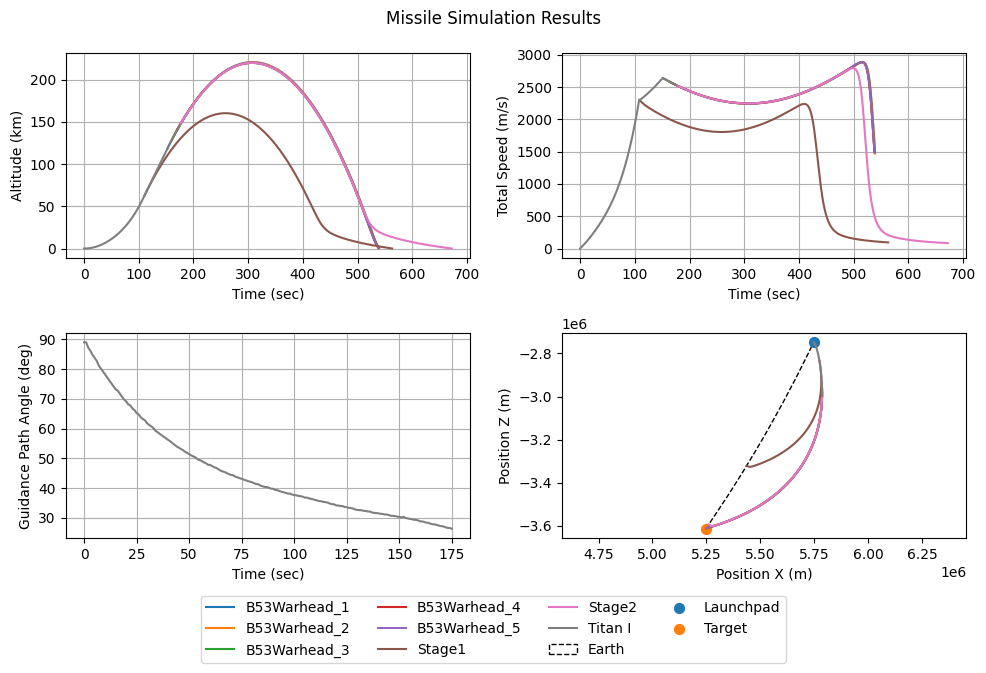

In [11]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 6))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="time", y="gamma_deg", hue="name", ax=ax[2])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[3], sort=False, errorbar=None)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Guidance Path Angle (deg)")

earth.plot_2D_with_points(points = [launchpad, target], ax=ax[3], display="arc")
ax[3].set_xlabel("Position X (m)")
ax[3].set_ylabel("Position Z (m)")
ax[3].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Missile Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)